# PR13 — Business Visualisation Principles; Interactive Plotly Chart Design

In [1]:
# ── Setup ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR = Path("../reports/figures")
INTERACTIVE_DIR = FIGURES_DIR / "interactive"
REPORTS_DIR = Path("../reports")
INTERACTIVE_DIR.mkdir(parents=True, exist_ok=True)

AS_OF_DATE = pd.Timestamp("2026-08-14")            # unchanged pipeline cutoff, notebooks 01-05
DATA_BOUNDARY_DATE = pd.Timestamp("2025-10-05")    # PR12: partial/boundary week, annotate not spike

# StreakForge brand palette — one source of truth, reused in every chart across PR13-16
BRAND = {
    "primary":   "#2E5EAA",   # neutral / informational series
    "retained":  "#1B9E77",   # green — retention / positive movement
    "churned":   "#D95F02",   # orange — churn / risk
    "high_risk": "#C0392B",   # red — high risk / anomaly
    "neutral":   "#7F8C8D",   # grey — baseline / rolling mean
    "highlight": "#F2C94C",   # amber — annotation / callout
    "bg":        "#FFFFFF",
    "grid":      "#E5E5E5",
}

def apply_streakforge_theme(fig, title, subtitle=None, height=460):
    """
    House chart theme, applied to every PR13-16 figure:
    - minimal gridlines (no chartjunk), consistent font/palette
    - title + one-line subtitle carrying the business takeaway, not just the axis labels
    - legend placed above the plot area so it never competes with data
    """
    full_title = f"<b>{title}</b>"
    if subtitle:
        full_title += f"<br><span style='font-size:12px;color:#7F8C8D'>{subtitle}</span>"
    fig.update_layout(
        title=dict(text=full_title, x=0.02, xanchor="left"),
        template="plotly_white",
        font=dict(family="Segoe UI, Arial", size=13, color="#2C3E50"),
        height=height,
        margin=dict(l=60, r=30, t=75, b=50),
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
        hoverlabel=dict(bgcolor="white", font_size=12),
        plot_bgcolor=BRAND["bg"],
    )
    fig.update_xaxes(showgrid=True, gridcolor=BRAND["grid"], zeroline=False)
    fig.update_yaxes(showgrid=True, gridcolor=BRAND["grid"], zeroline=False)
    return fig

def save_interactive(fig, name):
    """Persist as standalone HTML — the artefact PR16 packages and PR17+ Streamlit can embed via iframe."""
    path = INTERACTIVE_DIR / f"{name}.html"
    fig.write_html(path, include_plotlyjs="cdn")
    print(f"Saved: {path}")
    return path

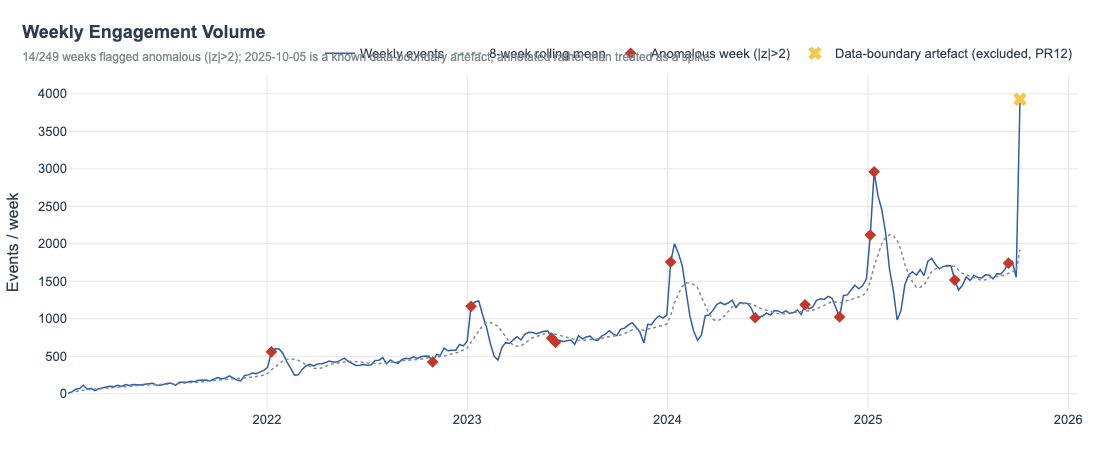

Saved: ../reports/figures/interactive/pr13_weekly_engagement_interactive.html


PosixPath('../reports/figures/interactive/pr13_weekly_engagement_interactive.html')

In [2]:
# ── 13.1 Weekly engagement volume — interactive, with anomalies (PR11) and boundary caveat (PR12) ──
weekly = pd.read_csv(PROCESSED_DIR / "weekly_engagement_anomalies.csv", parse_dates=["event_datetime"])
weekly["is_boundary_artifact"] = weekly["event_datetime"].eq(DATA_BOUNDARY_DATE)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=weekly["event_datetime"], y=weekly["event_count"], mode="lines", name="Weekly events",
    line=dict(color=BRAND["primary"], width=1.5),
    hovertemplate="Week of %{x|%d %b %Y}<br>Events: %{y:,}<extra></extra>",
))
fig.add_trace(go.Scatter(
    x=weekly["event_datetime"], y=weekly["rolling_mean"], mode="lines", name="8-week rolling mean",
    line=dict(color=BRAND["neutral"], width=1.5, dash="dot"),
))

anomalies = weekly.loc[weekly["is_anomaly"] & ~weekly["is_boundary_artifact"]]
fig.add_trace(go.Scatter(
    x=anomalies["event_datetime"], y=anomalies["event_count"], mode="markers", name="Anomalous week (|z|>2)",
    marker=dict(color=BRAND["high_risk"], size=9, symbol="diamond"),
    customdata=anomalies["z_score"],
    hovertemplate="Week of %{x|%d %b %Y}<br>Events: %{y:,}<br>z-score: %{customdata:.2f}<extra></extra>",
))

boundary = weekly.loc[weekly["is_boundary_artifact"]]
if not boundary.empty:
    fig.add_trace(go.Scatter(
        x=boundary["event_datetime"], y=boundary["event_count"], mode="markers",
        name="Data-boundary artefact (excluded, PR12)",
        marker=dict(color=BRAND["highlight"], size=12, symbol="x"),
        hovertemplate="Week of %{x|%d %b %Y}<br>Events: %{y:,}<br>Partial week at dataset edge — not a genuine spike (PR12)<extra></extra>",
    ))

apply_streakforge_theme(
    fig, "Weekly Engagement Volume",
    "14/249 weeks flagged anomalous (|z|>2); 2025-10-05 is a known data-boundary artefact, annotated rather than treated as a spike"
)
fig.update_yaxes(title="Events / week")
fig.show()
save_interactive(fig, "pr13_weekly_engagement_interactive")

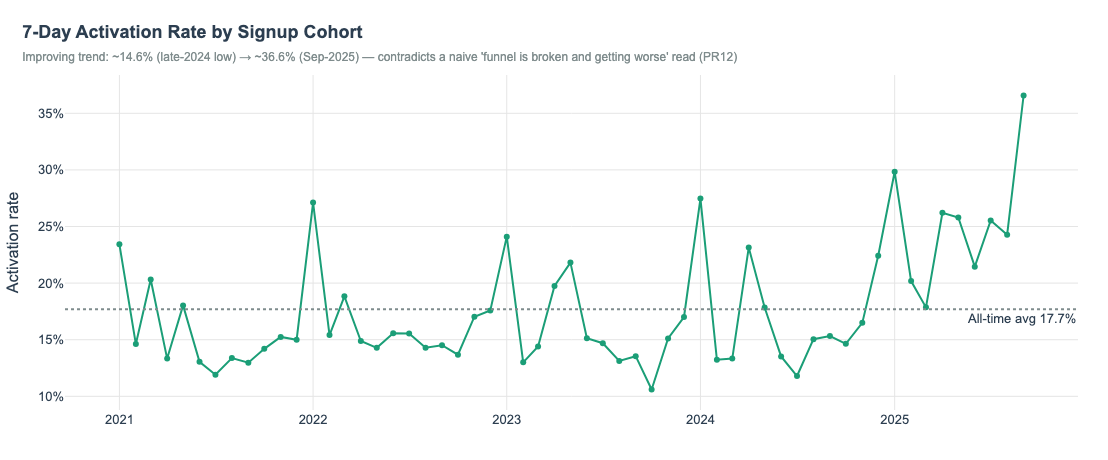

Saved: ../reports/figures/interactive/pr13_activation_cohort_interactive.html


PosixPath('../reports/figures/interactive/pr13_activation_cohort_interactive.html')

In [3]:
# ── 13.2 Activation cohort trend — interactive line, PR12's most encouraging finding ──
cohort = pd.read_csv(PROCESSED_DIR / "activation_cohort_trend.csv")
cohort["join_month"] = pd.to_datetime(cohort["join_month"], format="%Y-%m")

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=cohort["join_month"], y=cohort["activation_rate"], mode="lines+markers",
    line=dict(color=BRAND["retained"], width=2), marker=dict(size=6),
    customdata=cohort["members"],
    hovertemplate="Cohort: %{x|%b %Y}<br>Activation rate: %{y:.1%}<br>Members: %{customdata:,}<extra></extra>",
))
fig.add_hline(
    y=cohort["activation_rate"].mean(), line_dash="dot", line_color=BRAND["neutral"],
    annotation_text=f"All-time avg {cohort['activation_rate'].mean():.1%}", annotation_position="bottom right",
)
apply_streakforge_theme(
    fig, "7-Day Activation Rate by Signup Cohort",
    "Improving trend: ~14.6% (late-2024 low) → ~36.6% (Sep-2025) — contradicts a naive 'funnel is broken and getting worse' read (PR12)"
)
fig.update_yaxes(title="Activation rate", tickformat=".0%")
fig.show()
save_interactive(fig, "pr13_activation_cohort_interactive")

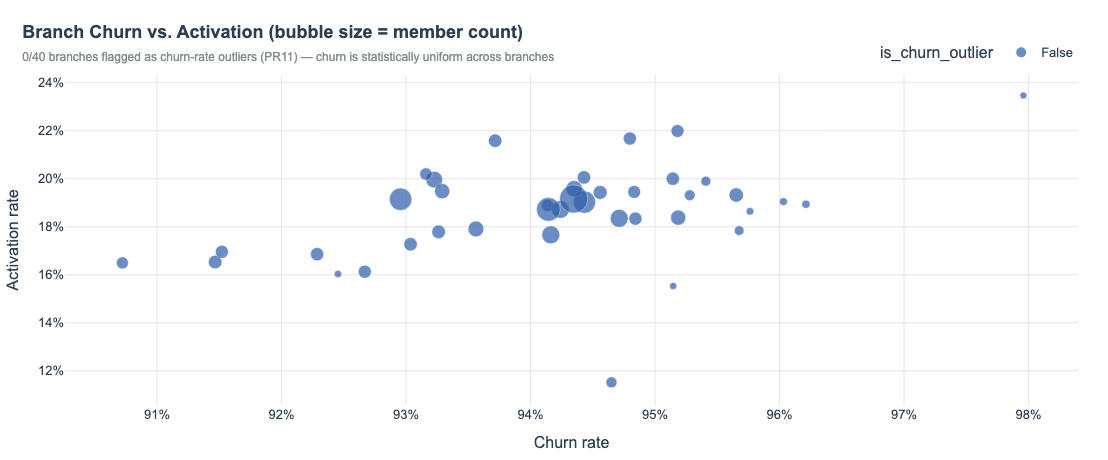

Saved: ../reports/figures/interactive/pr13_branch_risk_bubble_interactive.html


PosixPath('../reports/figures/interactive/pr13_branch_risk_bubble_interactive.html')

In [4]:
# ── 13.3 Branch churn vs. activation — interactive bubble chart ──
branch = pd.read_csv(PROCESSED_DIR / "branch_risk_summary.csv")

fig = px.scatter(
    branch, x="churn_rate", y="activation_rate", size="members", color="is_churn_outlier",
    color_discrete_map={False: BRAND["primary"], True: BRAND["high_risk"]},
    hover_name="gym_branch_id",
    hover_data={"members": ":,", "avg_sessions_per_week": ":.2f",
                "churn_rate": ":.1%", "activation_rate": ":.1%", "is_churn_outlier": False},
)
fig.update_traces(marker=dict(line=dict(width=0.5, color="white")))
apply_streakforge_theme(
    fig, "Branch Churn vs. Activation (bubble size = member count)",
    "0/40 branches flagged as churn-rate outliers (PR11) — churn is statistically uniform across branches"
)
fig.update_xaxes(title="Churn rate", tickformat=".0%")
fig.update_yaxes(title="Activation rate", tickformat=".0%")
fig.show()
save_interactive(fig, "pr13_branch_risk_bubble_interactive")

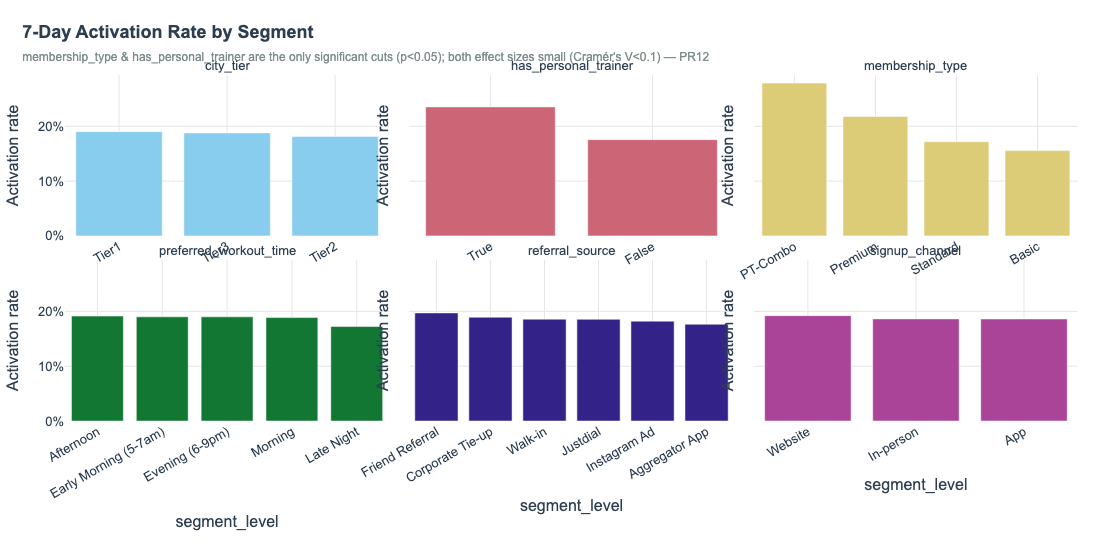

Saved: ../reports/figures/interactive/pr13_activation_by_segment_interactive.html


PosixPath('../reports/figures/interactive/pr13_activation_by_segment_interactive.html')

In [5]:
# ── 13.4 Activation rate by segment — faceted interactive bar (PR12 root-cause segments) ──
segments = pd.read_csv(PROCESSED_DIR / "activation_segment_comparison.csv")
segments = segments.sort_values(["segment_col", "activation_rate"], ascending=[True, False])

fig = px.bar(
    segments, x="segment_level", y="activation_rate", color="segment_col",
    facet_col="segment_col", facet_col_wrap=3,
    category_orders={"segment_col": sorted(segments["segment_col"].unique())},
    color_discrete_sequence=px.colors.qualitative.Safe,
    hover_data={"members": ":,", "cramers_v": ":.3f", "p_value": ":.3f",
                "activation_rate": ":.1%", "segment_col": False},
)
fig.update_xaxes(matches=None, showticklabels=True, tickangle=-30)
fig.update_yaxes(tickformat=".0%", title="Activation rate")
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
apply_streakforge_theme(
    fig, "7-Day Activation Rate by Segment",
    "membership_type & has_personal_trainer are the only significant cuts (p<0.05); both effect sizes small (Cramér's V<0.1) — PR12",
    height=540,
)
fig.update_layout(showlegend=False)
fig.show()
save_interactive(fig, "pr13_activation_by_segment_interactive")

# PR14 — KPI Card & Summary Metric Design

In [6]:
# ── Setup (fresh load, per-PR convention) ────────────────────────────────
kpi_df = pd.read_csv(PROCESSED_DIR / "kpi_summary.csv")
at_risk = pd.read_csv(PROCESSED_DIR / "at_risk_members.csv")

CATEGORY_COLOR = {
    "Retention": BRAND["churned"],
    "Acquisition & Activation": BRAND["primary"],
    "Revenue": BRAND["highlight"],
    "Engagement": BRAND["retained"],
    "Product / Streak Health": BRAND["neutral"],
}

def format_kpi_value(row):
    """Single formatting rule per unit type — the same function src/insights.py reuses for card display strings."""
    unit, v = row["unit"], row["value"]
    if unit == "%":
        return f"{v:.1%}"
    if unit == "INR":
        return f"₹{v:,.0f}"
    if unit == "INR/session":
        return f"₹{v:,.0f}/session"
    if unit == "count":
        return f"{v:,.0f}"
    if unit == "days":
        return f"{v:.1f} days"
    if unit == "sessions/wk":
        return f"{v:.2f}/wk"
    if unit == "CV":
        return f"{v:.2f}"
    return str(v)

In [7]:
# ── 14.1 KPI card spec table ──────────────────────────────────────────────
kpi_df["value_display"] = kpi_df.apply(format_kpi_value, axis=1)
kpi_df["card_color"] = kpi_df["category"].map(CATEGORY_COLOR).fillna(BRAND["neutral"])

# kpi_01/kpi_15 carry the AS_OF_DATE duality flagged in PR11 — surfaced as an explicit card footnote
# rather than silently dropped, per the project's "flag, don't silently fix" convention (PR6/PR11).
kpi_df["context_note"] = ""
kpi_df.loc[kpi_df["kpi_id"] == "kpi_01", "context_note"] = (
    "See kpi_15 — data-realistic as-of gives 84.0% (context only, does not replace this figure)."
)
kpi_df.loc[kpi_df["kpi_id"] == "kpi_15", "context_note"] = (
    "Supplementary context for kpi_01 only — not the pipeline's authoritative churn definition."
)

print(kpi_df[["kpi_id", "kpi_name", "value_display", "context_note"]].to_string(index=False))

kpi_id                          kpi_name  value_display                                                                                context_note
kpi_01                Overall Churn Rate          94.0% See kpi_15 — data-realistic as-of gives 84.0% (context only, does not replace this figure).
kpi_02            Overall Retention Rate           6.0%                                                                                            
kpi_03                    Active Members          1,011                                                                                            
kpi_04             7-Day Activation Rate          18.8%                                                                                            
kpi_05       Renewal Follow-Through Rate          42.3%                                                                                            
kpi_06         Median Revenue per Member         ₹8,970                                                         

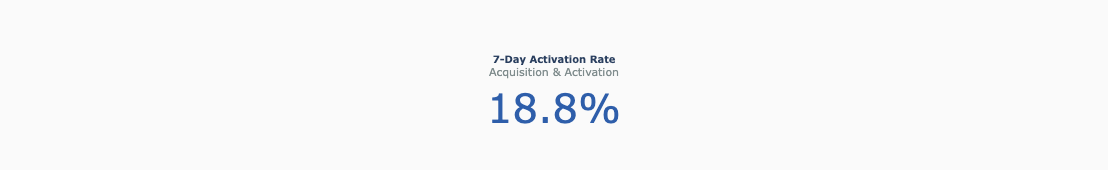

In [8]:
# ── 14.2 build_kpi_card() — single reusable card, same shape src/insights.py will call from Streamlit ──
def build_kpi_card(row, delta_reference=None):
    fig = go.Figure(go.Indicator(
        mode="number" + ("+delta" if delta_reference is not None else ""),
        value=row["value"],
        number={"valueformat": ",.1%" if row["unit"] == "%" else ",.0f",
                "font": {"color": row["card_color"], "size": 40}},
        delta={"reference": delta_reference} if delta_reference is not None else None,
        title={"text": f"<b>{row['kpi_name']}</b><br>"
                        f"<span style='font-size:11px;color:#7F8C8D'>{row['category']}</span>"},
    ))
    fig.update_layout(height=170, margin=dict(l=20, r=20, t=55, b=10), paper_bgcolor="#FAFAFA")
    return fig

# Example: single card for the platform's headline metric
build_kpi_card(kpi_df.loc[kpi_df["kpi_id"] == "kpi_04"].iloc[0]).show()

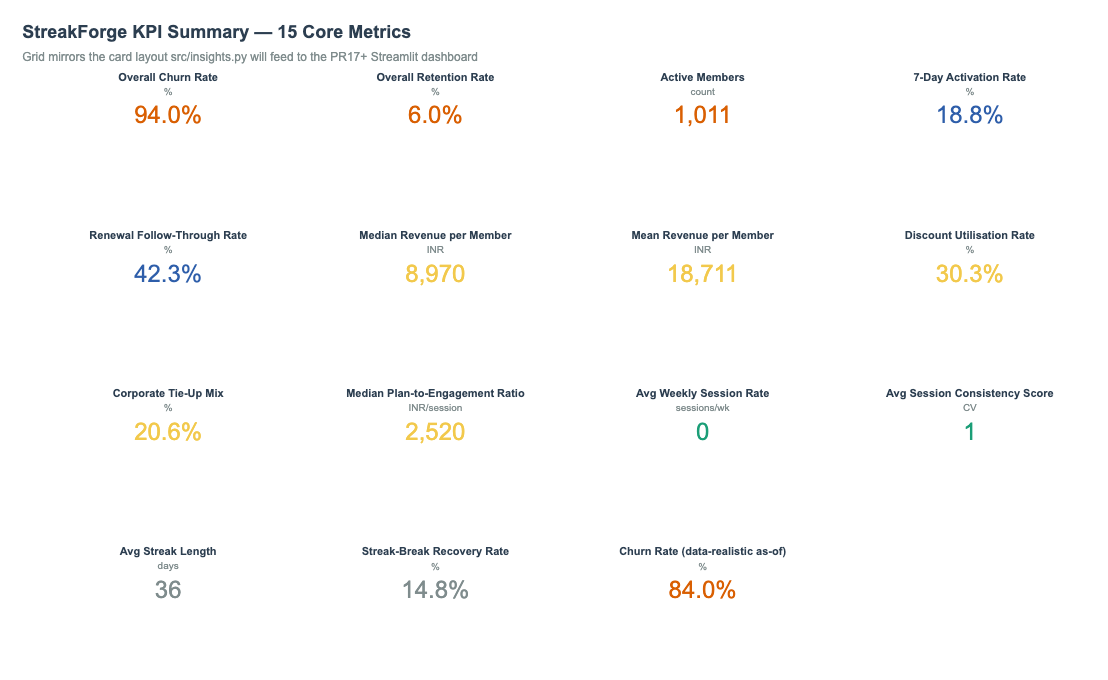

Saved: ../reports/figures/interactive/pr14_kpi_card_grid.html


PosixPath('../reports/figures/interactive/pr14_kpi_card_grid.html')

In [9]:
# ── 14.3 Full KPI card grid — all 15 KPIs, laid out the way the Streamlit dashboard will render them ──
cols = 4
n = len(kpi_df)
rows = -(-n // cols)  # ceil division

fig = make_subplots(
    rows=rows, cols=cols,
    specs=[[{"type": "indicator"}] * cols for _ in range(rows)],
    vertical_spacing=0.14, horizontal_spacing=0.05,
)

for i, row in kpi_df.reset_index(drop=True).iterrows():
    r, c = divmod(i, cols)
    valuefmt = ",.1%" if row["unit"] == "%" else ",.0f"
    fig.add_trace(go.Indicator(
        mode="number",
        value=row["value"],
        number={"valueformat": valuefmt, "font": {"size": 24, "color": row["card_color"]}},
        title={"text": f"<b>{row['kpi_name']}</b><br>"
                        f"<span style='font-size:10px;color:#7F8C8D'>{row['unit']}</span>",
               "font": {"size": 11}},
    ), row=r + 1, col=c + 1)

apply_streakforge_theme(
    fig, "StreakForge KPI Summary — 15 Core Metrics",
    "Grid mirrors the card layout src/insights.py will feed to the PR17+ Streamlit dashboard",
    height=170 * rows,
)
fig.show()
save_interactive(fig, "pr14_kpi_card_grid")

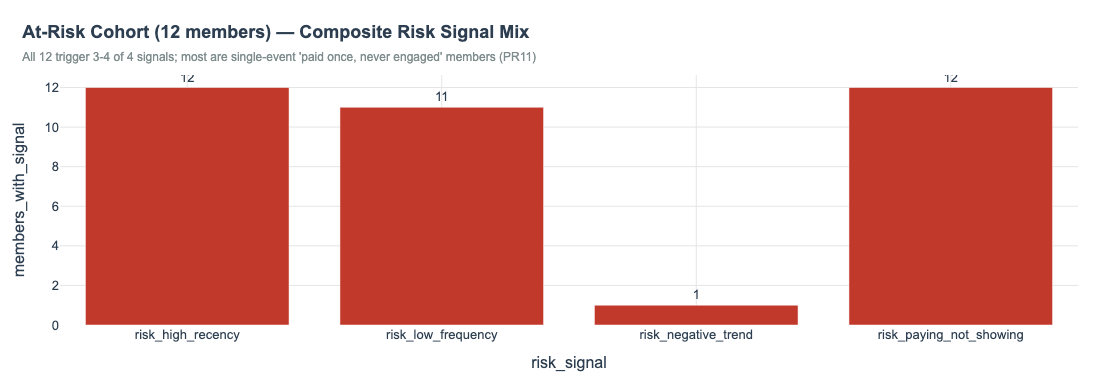

Saved: ../reports/figures/interactive/pr14_at_risk_signal_mix.html


PosixPath('../reports/figures/interactive/pr14_at_risk_signal_mix.html')

In [10]:
# ── 14.4 At-risk cohort signal-mix card ────────────────────────────────────
# at_risk_members.csv is already scoped to the 12 "High"-risk members (PR11 §11.2.3);
# this reports the composite signal mix within that group, not a full risk-tier breakdown
# (risk_tier itself isn't persisted onto this file, only the risk_high_recency/etc. flags).
signal_cols = ["risk_high_recency", "risk_low_frequency", "risk_negative_trend", "risk_paying_not_showing"]
signal_mix = (at_risk[signal_cols].sum()
              .rename("members_with_signal").reset_index()
              .rename(columns={"index": "risk_signal"}))

fig = px.bar(signal_mix, x="risk_signal", y="members_with_signal", text="members_with_signal")
fig.update_traces(marker_color=BRAND["high_risk"], textposition="outside")
apply_streakforge_theme(
    fig, f"At-Risk Cohort ({len(at_risk)} members) — Composite Risk Signal Mix",
    "All 12 trigger 3-4 of 4 signals; most are single-event 'paid once, never engaged' members (PR11)",
    height=380,
)
fig.update_layout(showlegend=False)
fig.show()
save_interactive(fig, "pr14_at_risk_signal_mix")

In [11]:
# ── Persist the card spec for reuse by PR16 / src/insights.py ────────────
kpi_cards_spec = kpi_df[["kpi_id", "kpi_name", "category", "value", "unit",
                          "value_display", "card_color", "context_note"]]
kpi_cards_spec.to_csv(PROCESSED_DIR / "kpi_cards_spec.csv", index=False)
print(f"Saved: {PROCESSED_DIR / 'kpi_cards_spec.csv'}  ({kpi_cards_spec.shape[0]} rows)")

Saved: ../data/processed/kpi_cards_spec.csv  (15 rows)


# PR15 — Data Storytelling & Insight Narrative; Executive Reporting & Stakeholder Communication

In [12]:
# ── Setup (fresh load) ────────────────────────────────────────────────────
kpi_df = pd.read_csv(PROCESSED_DIR / "kpi_summary.csv")
cohort = pd.read_csv(PROCESSED_DIR / "activation_cohort_trend.csv")
cohort["join_month"] = pd.to_datetime(cohort["join_month"], format="%Y-%m")
branch = pd.read_csv(PROCESSED_DIR / "branch_risk_summary.csv")
at_risk = pd.read_csv(PROCESSED_DIR / "at_risk_members.csv")

def kpi(kpi_id):
    return kpi_df.loc[kpi_df["kpi_id"] == kpi_id, "value"].iloc[0]

In [13]:
# ── 15.1 Insight narrative table — reusable rows for reports/insight_summary.md and the app ──
# Each row follows a fixed shape (headline / narrative / evidence / impact / audience / action /
# confidence), the same discipline PR12's investigation log established, but written for a
# stakeholder audience rather than an analyst one.
insight_rows = [
    {
        "insight_id": "INS-01",
        "headline": "Churn looks catastrophic (94%) but is largely a measurement artefact, not a business crisis",
        "narrative": (
            f"The pipeline's fixed AS_OF_DATE (2026-08-14) sits well past the dataset's actual last "
            f"event (2025-10-05), so almost every member reads as churned. Re-anchoring to a data-realistic "
            f"as-of date drops churn to {kpi('kpi_15'):.1%} (kpi_15) — still high, but the headline "
            f"{kpi('kpi_01'):.1%} should never be quoted to leadership without this context."
        ),
        "supporting_evidence": "kpi_01 vs kpi_15 (kpi_summary.csv); PR9/PR11 AS_OF_DATE decision.",
        "business_impact": "High — wrong framing risks over-reacting (e.g. panic win-back spend) to a partly artefactual stat.",
        "audience": "Leadership / Finance",
        "recommended_action": "Always report churn with both figures side by side; treat kpi_15 as the operationally meaningful number.",
        "confidence": "High",
    },
    {
        "insight_id": "INS-02",
        "headline": "Activation, not renewal, is where the platform loses members",
        "narrative": (
            f"Only {kpi('kpi_04'):.1%} of members log any activity within 7 days of joining (PR10 funnel: "
            "81.2% drop-off at this single stage — the largest of any funnel step). No acquisition channel "
            "or demographic segment explains it (all Cramér's V < 0.1, PR12)."
        ),
        "supporting_evidence": "kpi_04 (kpi_summary.csv); activation_segment_comparison.csv; PR10 funnel.",
        "business_impact": "High — the single highest-leverage retention lever found in the dataset.",
        "audience": "Product / Growth",
        "recommended_action": "Prioritise onboarding UX/timing experiments over channel-targeted acquisition spend.",
        "confidence": "Medium-High",
    },
    {
        "insight_id": "INS-03",
        "headline": "Activation is quietly improving — the funnel is not 'getting worse'",
        "narrative": (
            "Monthly cohort activation rate rose from ~14.6% (late 2024) to ~36.6% (Sep 2025) — the most "
            "encouraging non-obvious finding in the dataset, and the opposite of what the 81.2% headline "
            "drop-off implies in isolation."
        ),
        "supporting_evidence": "activation_cohort_trend.csv; PR12 §12.1(b).",
        "business_impact": "Medium — reframes the narrative from 'broken funnel' to 'improving, keep investing'.",
        "audience": "Leadership / Product",
        "recommended_action": "Investigate what changed operationally in early 2025 and double down on it.",
        "confidence": "Medium",
    },
    {
        "insight_id": "INS-04",
        "headline": "Churn and activation are platform-wide problems, not a branch-operations issue",
        "narrative": (
            "0 of 40 branches are statistical churn-rate outliers, and 0 branches compound a churn anomaly "
            "with bottom-quartile activation — ruling out 'a few bad branches' as the root cause."
        ),
        "supporting_evidence": "branch_risk_summary.csv (0/40 flagged); PR11 §11.2.2, PR12 §12.1(c).",
        "business_impact": "Medium — redirects investigation away from branch staffing/ops toward product/onboarding.",
        "audience": "Operations",
        "recommended_action": "Do not fund a branch-level operational audit as a churn fix; focus centrally on onboarding.",
        "confidence": "Medium",
    },
    {
        "insight_id": "INS-05",
        "headline": "A small, well-defined 'paid once, never engaged' cohort is ready for direct outreach",
        "narrative": (
            f"{len(at_risk)} currently-active members trigger nearly all composite risk signals — mostly "
            "single-event members paying ₹48K–₹102K per logged session. A short, actionable list, not a "
            "diffuse population-wide signal."
        ),
        "supporting_evidence": "at_risk_members.csv (12 rows); PR11 §11.2.3.",
        "business_impact": "Medium — small volume, but high win-back value per member and low targeting cost.",
        "audience": "Customer Success",
        "recommended_action": "Direct outreach (call / PT trial offer) to the 12 flagged members within the next billing cycle.",
        "confidence": "High",
    },
]

insight_narrative = pd.DataFrame(insight_rows)
print(insight_narrative[["insight_id", "headline", "audience", "confidence"]].to_string(index=False))
insight_narrative.to_csv(PROCESSED_DIR / "insight_narrative.csv", index=False)

insight_id                                                                                    headline             audience  confidence
    INS-01 Churn looks catastrophic (94%) but is largely a measurement artefact, not a business crisis Leadership / Finance        High
    INS-02                                Activation, not renewal, is where the platform loses members     Product / Growth Medium-High
    INS-03                         Activation is quietly improving — the funnel is not 'getting worse' Leadership / Product      Medium
    INS-04              Churn and activation are platform-wide problems, not a branch-operations issue           Operations      Medium
    INS-05        A small, well-defined 'paid once, never engaged' cohort is ready for direct outreach     Customer Success        High


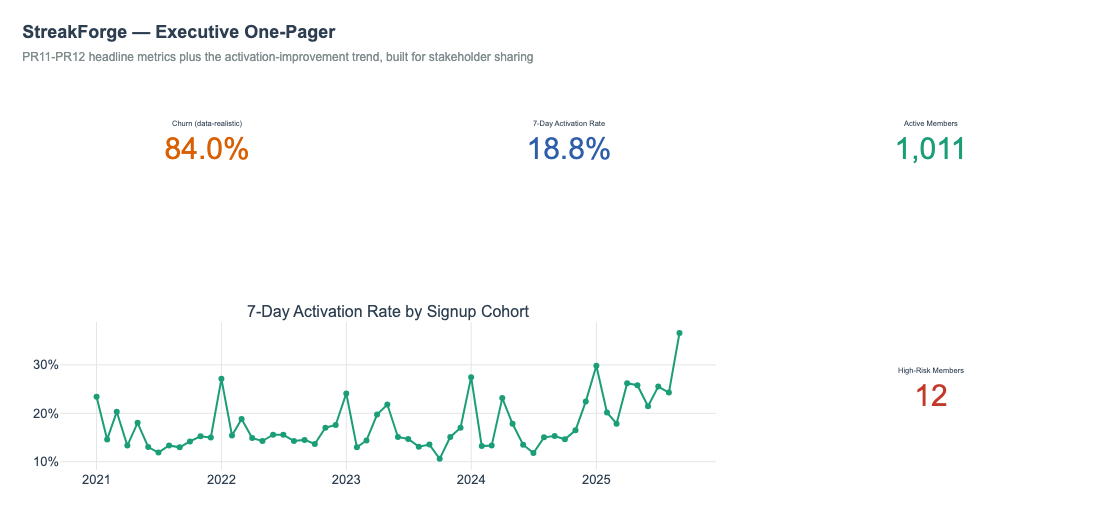

Saved: ../reports/figures/interactive/pr15_executive_one_pager.html


PosixPath('../reports/figures/interactive/pr15_executive_one_pager.html')

In [14]:
# ── 15.2 Executive one-pager — a single shareable figure combining the headline numbers + trend ──
fig = make_subplots(
    rows=2, cols=3,
    specs=[[{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}],
           [{"type": "xy", "colspan": 2}, None, {"type": "indicator"}]],
    subplot_titles=("", "", "", "7-Day Activation Rate by Signup Cohort", ""),
)

fig.add_trace(go.Indicator(
    mode="number", value=kpi("kpi_15"),
    number={"valueformat": ".1%", "font": {"color": BRAND["churned"], "size": 30}},
    title={"text": "Churn (data-realistic)"},
), row=1, col=1)
fig.add_trace(go.Indicator(
    mode="number", value=kpi("kpi_04"),
    number={"valueformat": ".1%", "font": {"color": BRAND["primary"], "size": 30}},
    title={"text": "7-Day Activation Rate"},
), row=1, col=2)
fig.add_trace(go.Indicator(
    mode="number", value=kpi("kpi_03"),
    number={"valueformat": ",.0f", "font": {"color": BRAND["retained"], "size": 30}},
    title={"text": "Active Members"},
), row=1, col=3)
fig.add_trace(go.Scatter(
    x=cohort["join_month"], y=cohort["activation_rate"], mode="lines+markers",
    line=dict(color=BRAND["retained"], width=2), showlegend=False,
), row=2, col=1)
fig.add_trace(go.Indicator(
    mode="number", value=len(at_risk),
    number={"valueformat": ",.0f", "font": {"color": BRAND["high_risk"], "size": 30}},
    title={"text": "High-Risk Members"},
), row=2, col=3)

apply_streakforge_theme(
    fig, "StreakForge — Executive One-Pager",
    "PR11-PR12 headline metrics plus the activation-improvement trend, built for stakeholder sharing",
    height=520,
)
fig.update_yaxes(tickformat=".0%", row=2, col=1)
fig.show()
save_interactive(fig, "pr15_executive_one_pager")

## 15.3 Narrative arc
### The StreakForge Story — Situation / Complication / Resolution

**Situation:** StreakForge has ~17,500 members and a 94.0% headline churn rate — on the surface,
a platform in crisis.

**Complication:** That number is misleading on two fronts. First, it's inflated by an AS_OF_DATE
sitting ~10 months past the dataset's real activity window (data-realistic churn: 84.0%). Second,
the real leak isn't renewal or long-term retention at all — 81.2% of members never engage even
once within 7 days of signing up, and no acquisition channel, demographic, or branch explains why.

**Resolution:** The fix is narrow and improving on its own. Activation-cohort trend shows the
platform already climbing from ~14.6% to ~36.6% activation over the last year, with no branch-level
operational failure dragging it down. The recommended focus for the next quarter is a single lever —
onboarding UX/timing in the first 7 days — plus a small, concrete 12-member outreach list for
immediate win-back value.

# PR16 — Insight Export & Report Generation

In [15]:
# ── Setup (fresh load) ────────────────────────────────────────────────────
kpi_cards_spec = pd.read_csv(PROCESSED_DIR / "kpi_cards_spec.csv")
insight_narrative = pd.read_csv(PROCESSED_DIR / "insight_narrative.csv")

In [16]:
# ── 16.1 Generate reports/insight_summary.md programmatically ────────────
# Per PRD Documentation Standards: this file should be updated incrementally throughout the
# project, not written only at the end — PR16 consolidates everything into its final polished form.
def generate_insight_summary_md():
    lines = [
        "# StreakForge — Insight Summary",
        "",
        f"_Generated by 06_visualisation_and_storytelling.ipynb — AS_OF_DATE {AS_OF_DATE.date()}_",
        "",
        "## Core KPIs",
        "",
        "| KPI | Category | Value | Unit |",
        "|---|---|---|---|",
    ]
    for _, r in kpi_cards_spec.iterrows():
        lines.append(f"| {r['kpi_name']} | {r['category']} | {r['value_display']} | {r['unit']} |")

    lines += ["", "## Key Insights", ""]
    for _, r in insight_narrative.iterrows():
        lines += [
            f"### {r['insight_id']} — {r['headline']}", "",
            r["narrative"], "",
            f"**Evidence:** {r['supporting_evidence']}  ",
            f"**Business impact:** {r['business_impact']}  ",
            f"**Audience:** {r['audience']}  ",
            f"**Recommended action:** {r['recommended_action']}  ",
            f"**Confidence:** {r['confidence']}", "",
        ]
    return "\n".join(lines)

summary_md = generate_insight_summary_md()
(REPORTS_DIR / "insight_summary.md").write_text(summary_md, encoding="utf-8")
print(f"Saved: {REPORTS_DIR / 'insight_summary.md'}  ({len(summary_md.splitlines())} lines)")
print(summary_md[:600])

Saved: ../reports/insight_summary.md  (75 lines)
# StreakForge — Insight Summary

_Generated by 06_visualisation_and_storytelling.ipynb — AS_OF_DATE 2026-08-14_

## Core KPIs

| KPI | Category | Value | Unit |
|---|---|---|---|
| Overall Churn Rate | Retention | 94.0% | % |
| Overall Retention Rate | Retention | 6.0% | % |
| Active Members | Retention | 1,011 | count |
| 7-Day Activation Rate | Acquisition & Activation | 18.8% | % |
| Renewal Follow-Through Rate | Acquisition & Activation | 42.3% | % |
| Median Revenue per Member | Revenue | ₹8,970 | INR |
| Mean Revenue per Member | Revenue | ₹18,711 | INR |
| Discount Utilisation Rate | Re


In [17]:
# ── 16.2 Deliverables manifest — every artefact PR13-16 produced, for handoff / PR17 reference ──
deliverable_rows = []
for f in sorted(FIGURES_DIR.glob("*.png")):
    deliverable_rows.append({"artifact": f.name, "type": "static_chart", "path": str(f)})
for f in sorted(INTERACTIVE_DIR.glob("*.html")):
    deliverable_rows.append({"artifact": f.name, "type": "interactive_chart", "path": str(f)})
for f in sorted(PROCESSED_DIR.glob("*.csv")):
    deliverable_rows.append({"artifact": f.name, "type": "data_csv", "path": str(f)})
deliverable_rows.append({"artifact": "insight_summary.md", "type": "report", "path": str(REPORTS_DIR / "insight_summary.md")})

deliverables = pd.DataFrame(deliverable_rows)
deliverables.to_csv(PROCESSED_DIR / "deliverables_manifest.csv", index=False)
print(deliverables["type"].value_counts())

type
static_chart         13
data_csv             11
interactive_chart     7
report                1
Name: count, dtype: int64


In [18]:
# ── 16.3 JSON export — the exact shape src/insights.py will load for the Streamlit app ──
import json

insights_payload = {
    "as_of_date": str(AS_OF_DATE.date()),
    "kpis": kpi_cards_spec.to_dict(orient="records"),
    "insights": insight_narrative.to_dict(orient="records"),
}
with open(PROCESSED_DIR / "insights_payload.json", "w", encoding="utf-8") as fh:
    json.dump(insights_payload, fh, indent=2, default=str)
print(f"Saved: {PROCESSED_DIR / 'insights_payload.json'}")

Saved: ../data/processed/insights_payload.json


In [19]:
# ── 16.4 Final notebook summary ────────────────────────────────────────────
print("06_visualisation_and_storytelling.ipynb — PR13-16 complete")
print(f"  Interactive charts : {len(list(INTERACTIVE_DIR.glob('*.html')))}")
print(f"  KPI cards          : {len(kpi_cards_spec)}")
print(f"  Insight narratives : {len(insight_narrative)}")
print(f"  Deliverables       : {len(deliverables)}")
print(f"  Report             : {REPORTS_DIR / 'insight_summary.md'}")

06_visualisation_and_storytelling.ipynb — PR13-16 complete
  Interactive charts : 7
  KPI cards          : 15
  Insight narratives : 5
  Deliverables       : 32
  Report             : ../reports/insight_summary.md
